--- TAHAP 1: GATHERING & PRE-PROCESSING DATA ---
Loading data...
Jumlah baris awal: 1,067,371
Jumlah baris setelah pre-processing (Data Bersih): 805,549
Rentang Waktu Data: 2009-12-01 hingga 2011-12-09

--- TAHAP 2: MEMULAI GENERATE GRAFIK EDA ---
Generating Plot 1: Countplot Musiman per Bulan...


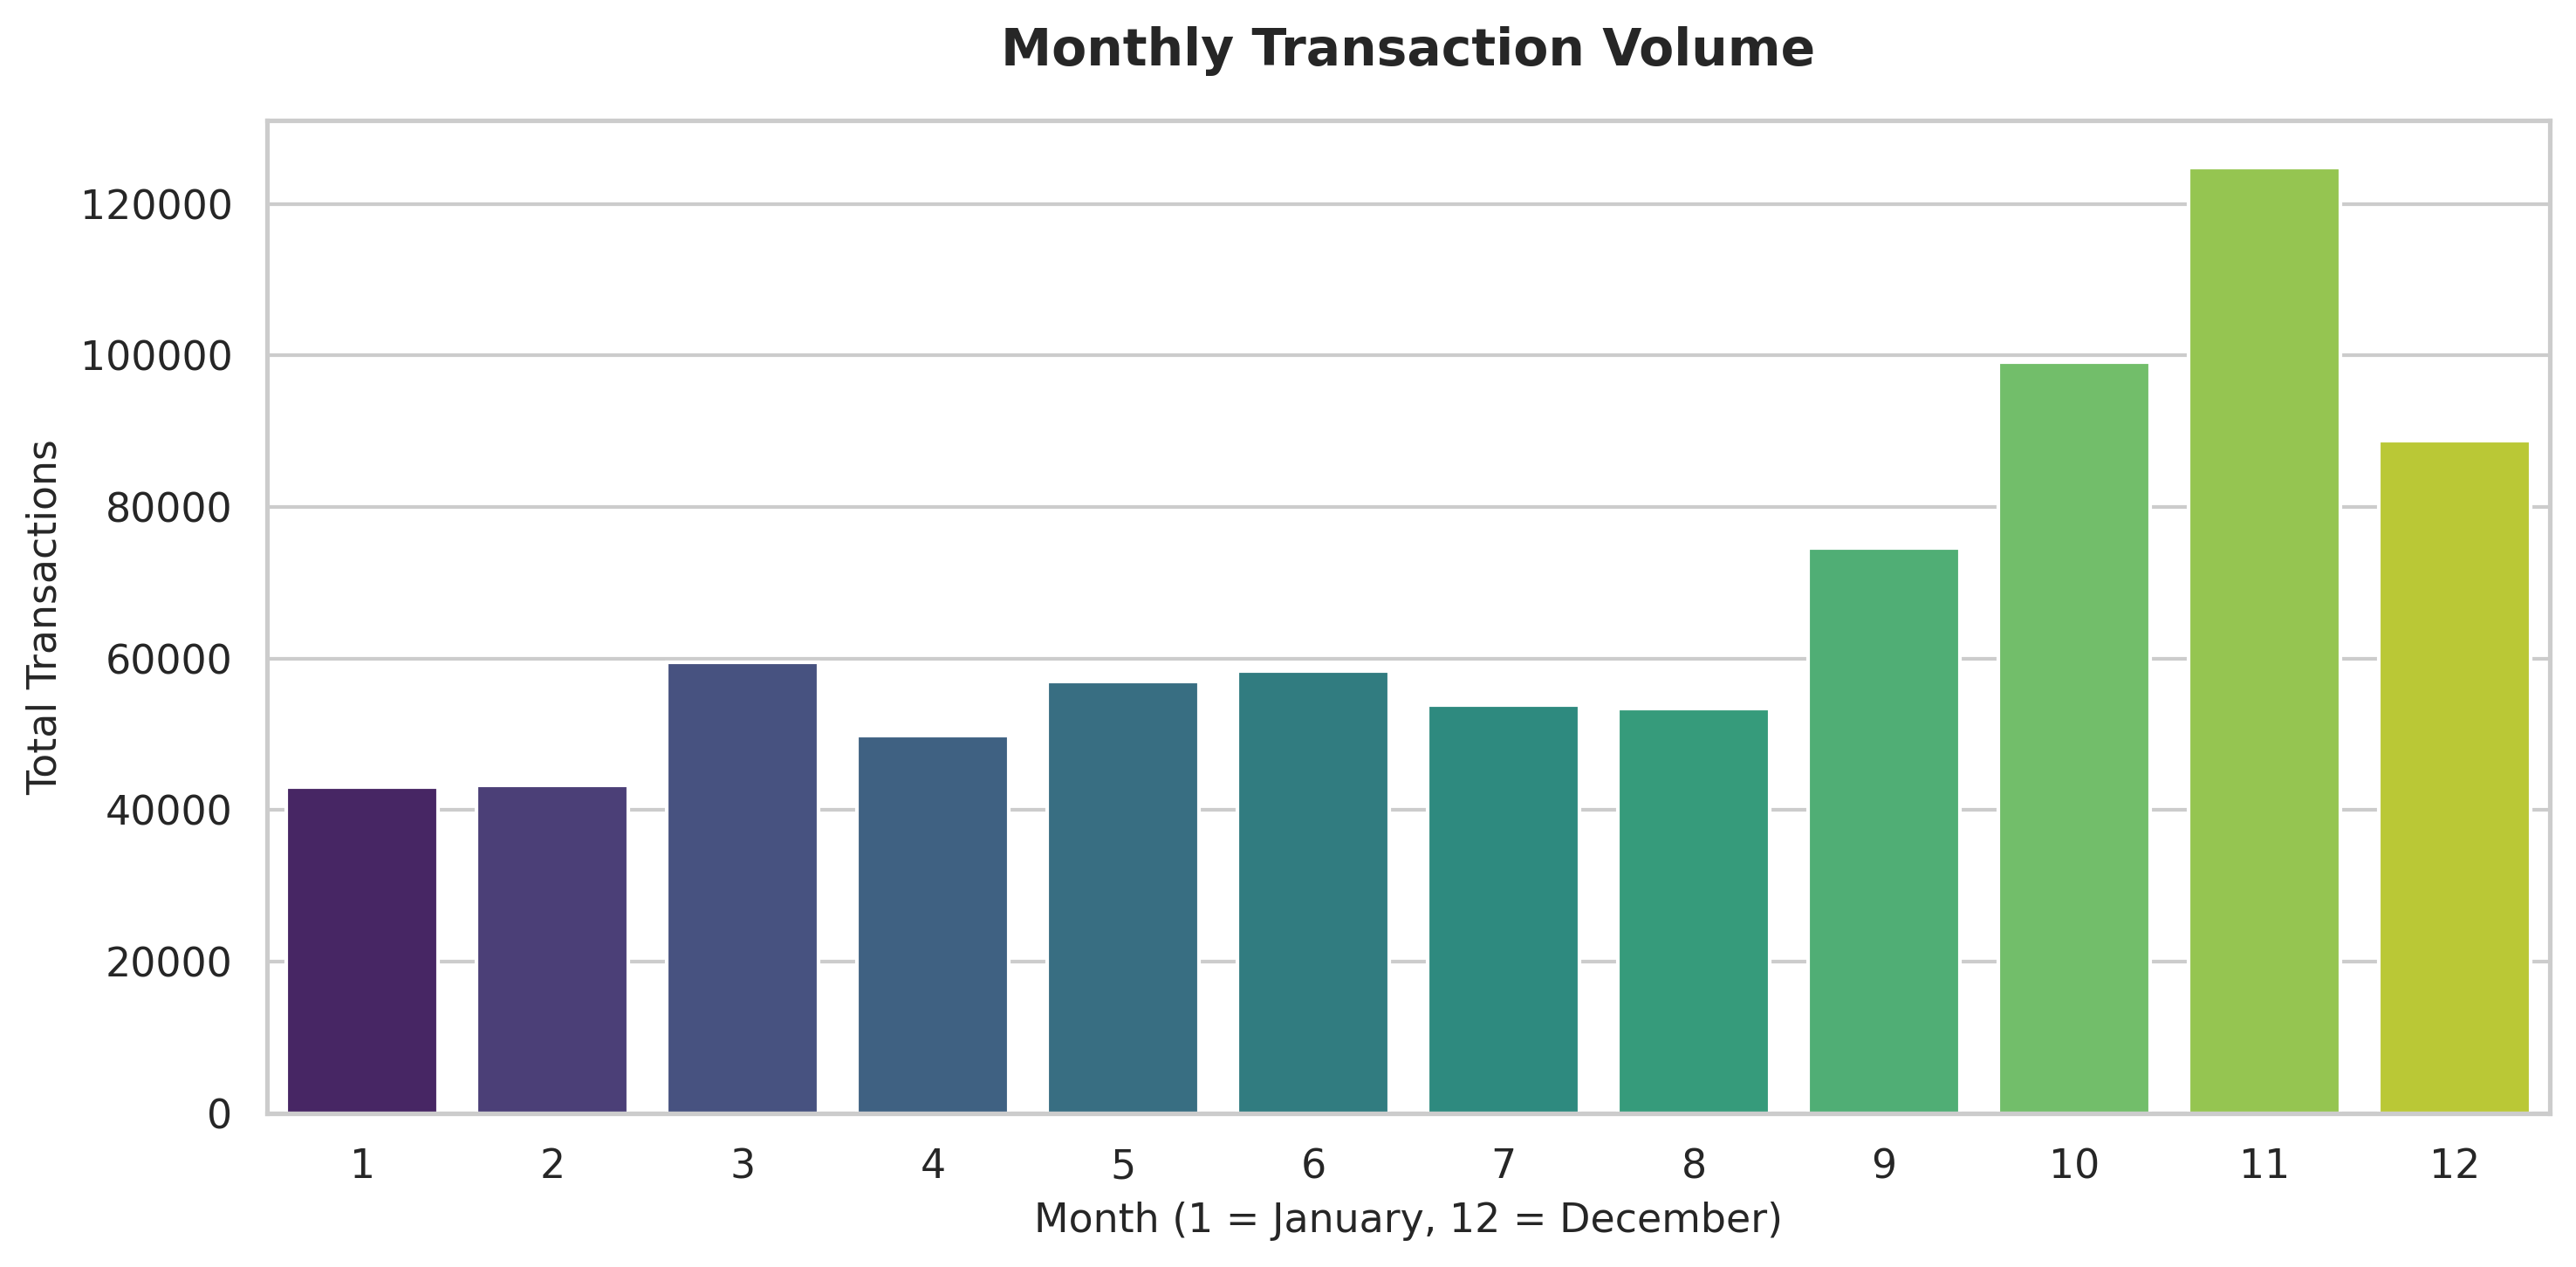

Generating Plot 2: Histplot Distribusi Fitur...


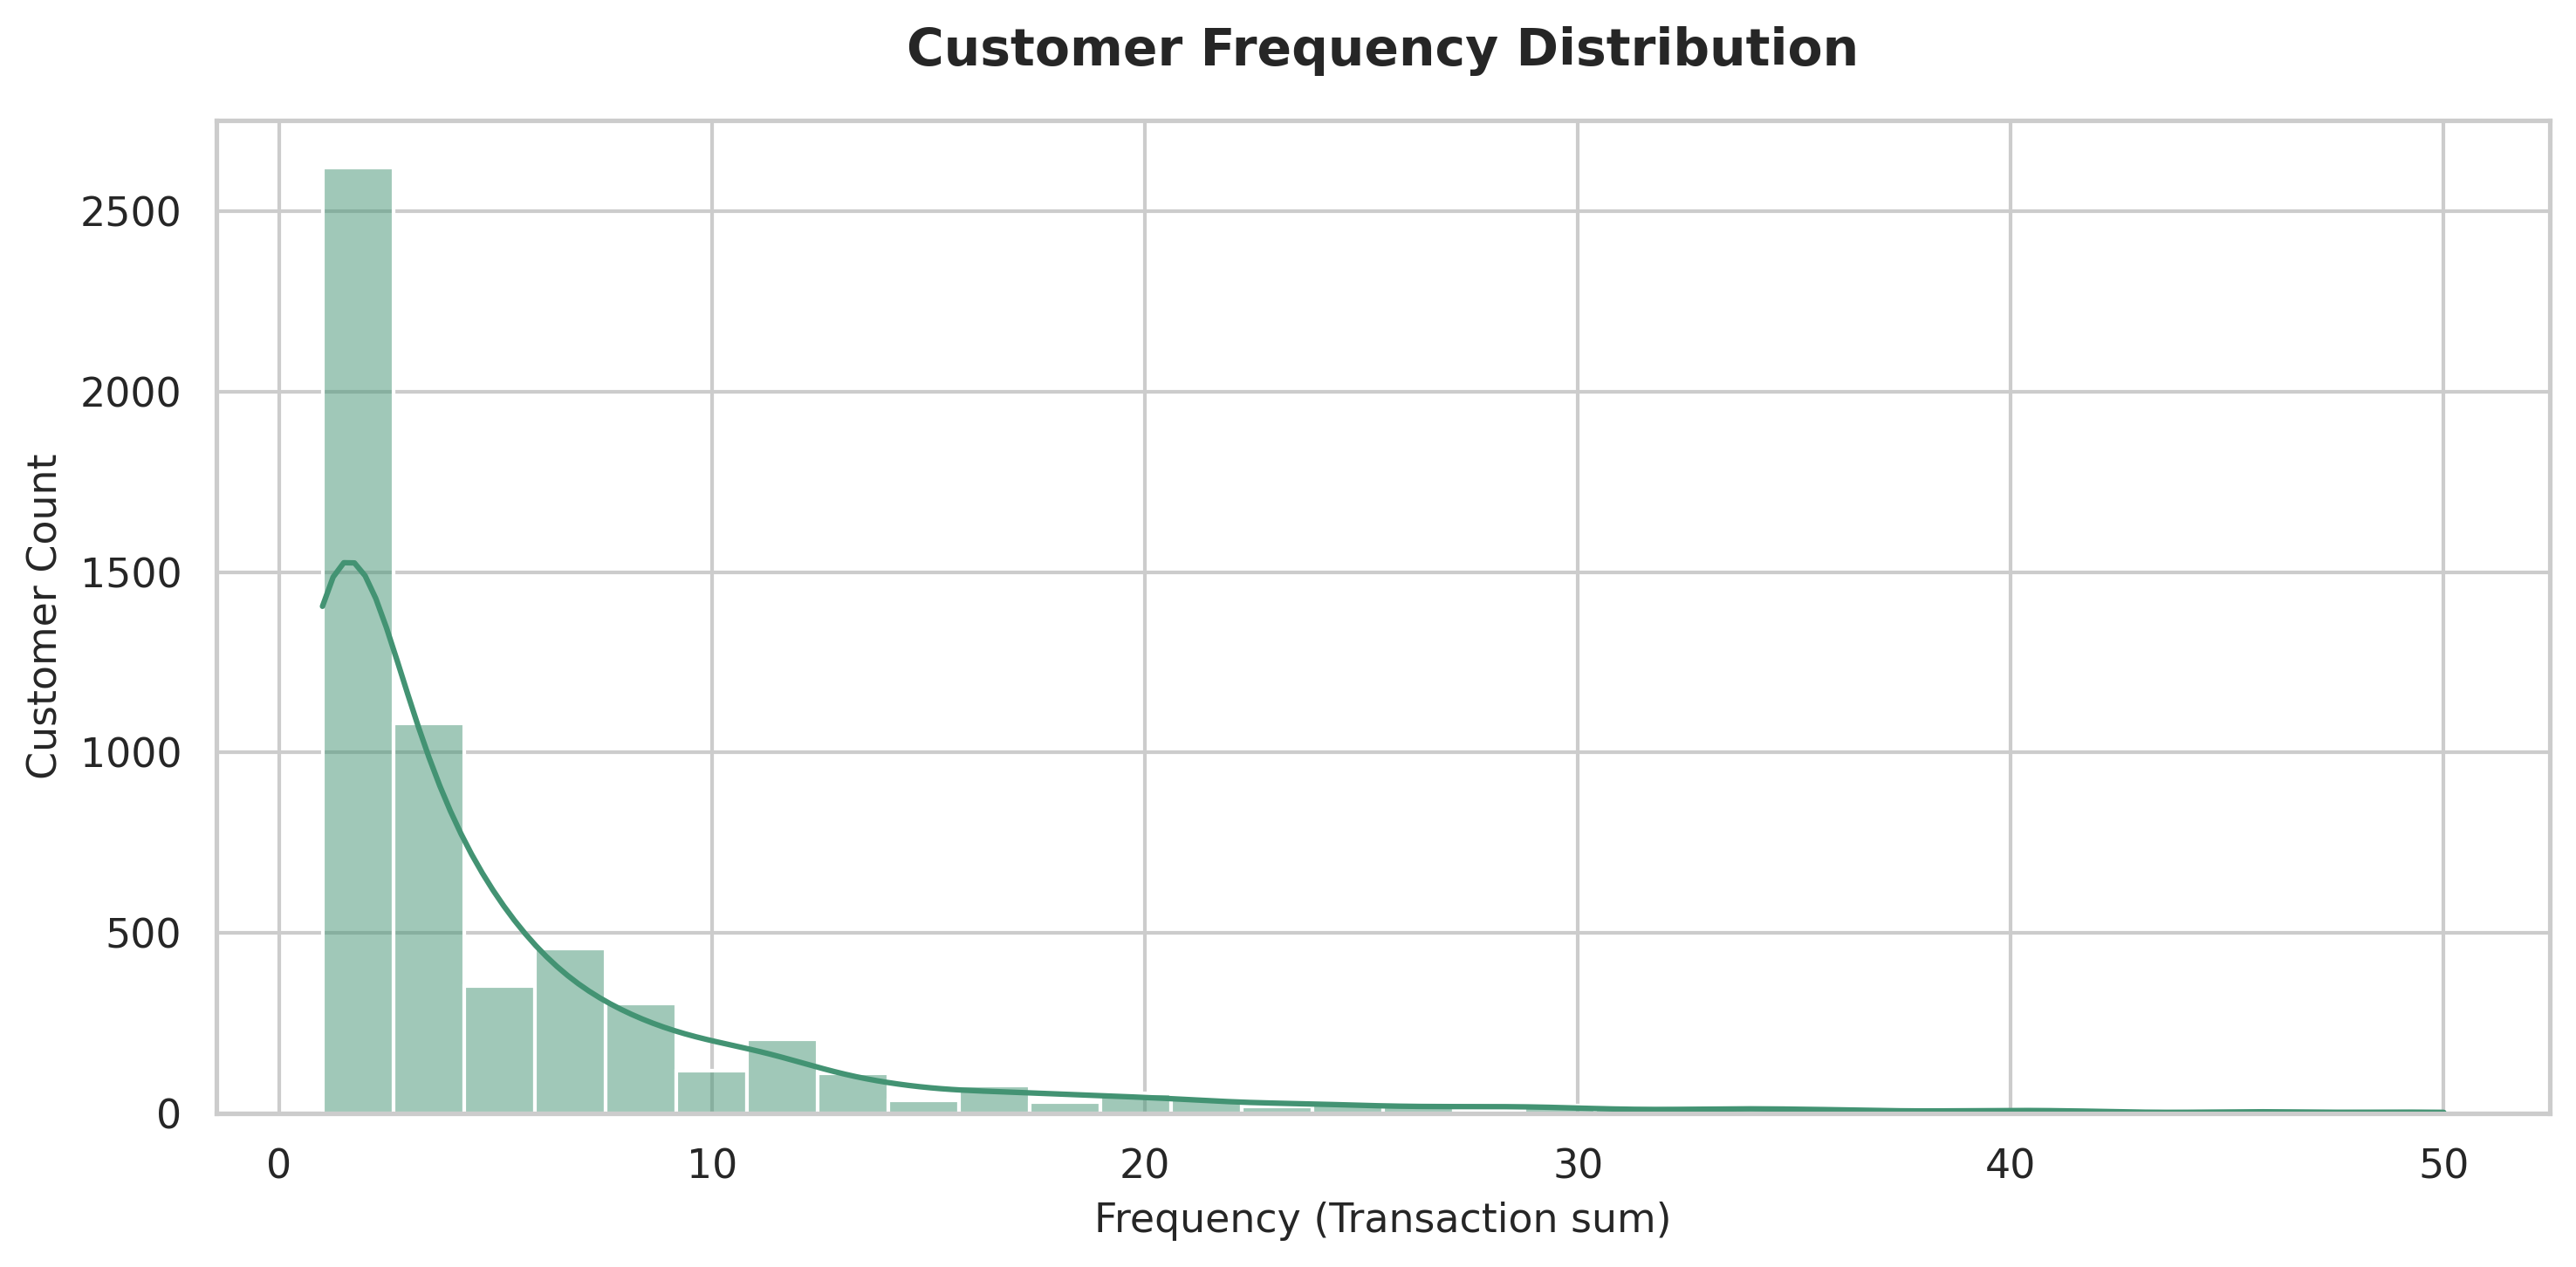

Generating Plot 3: Scatter Plot Recency vs Frequency...


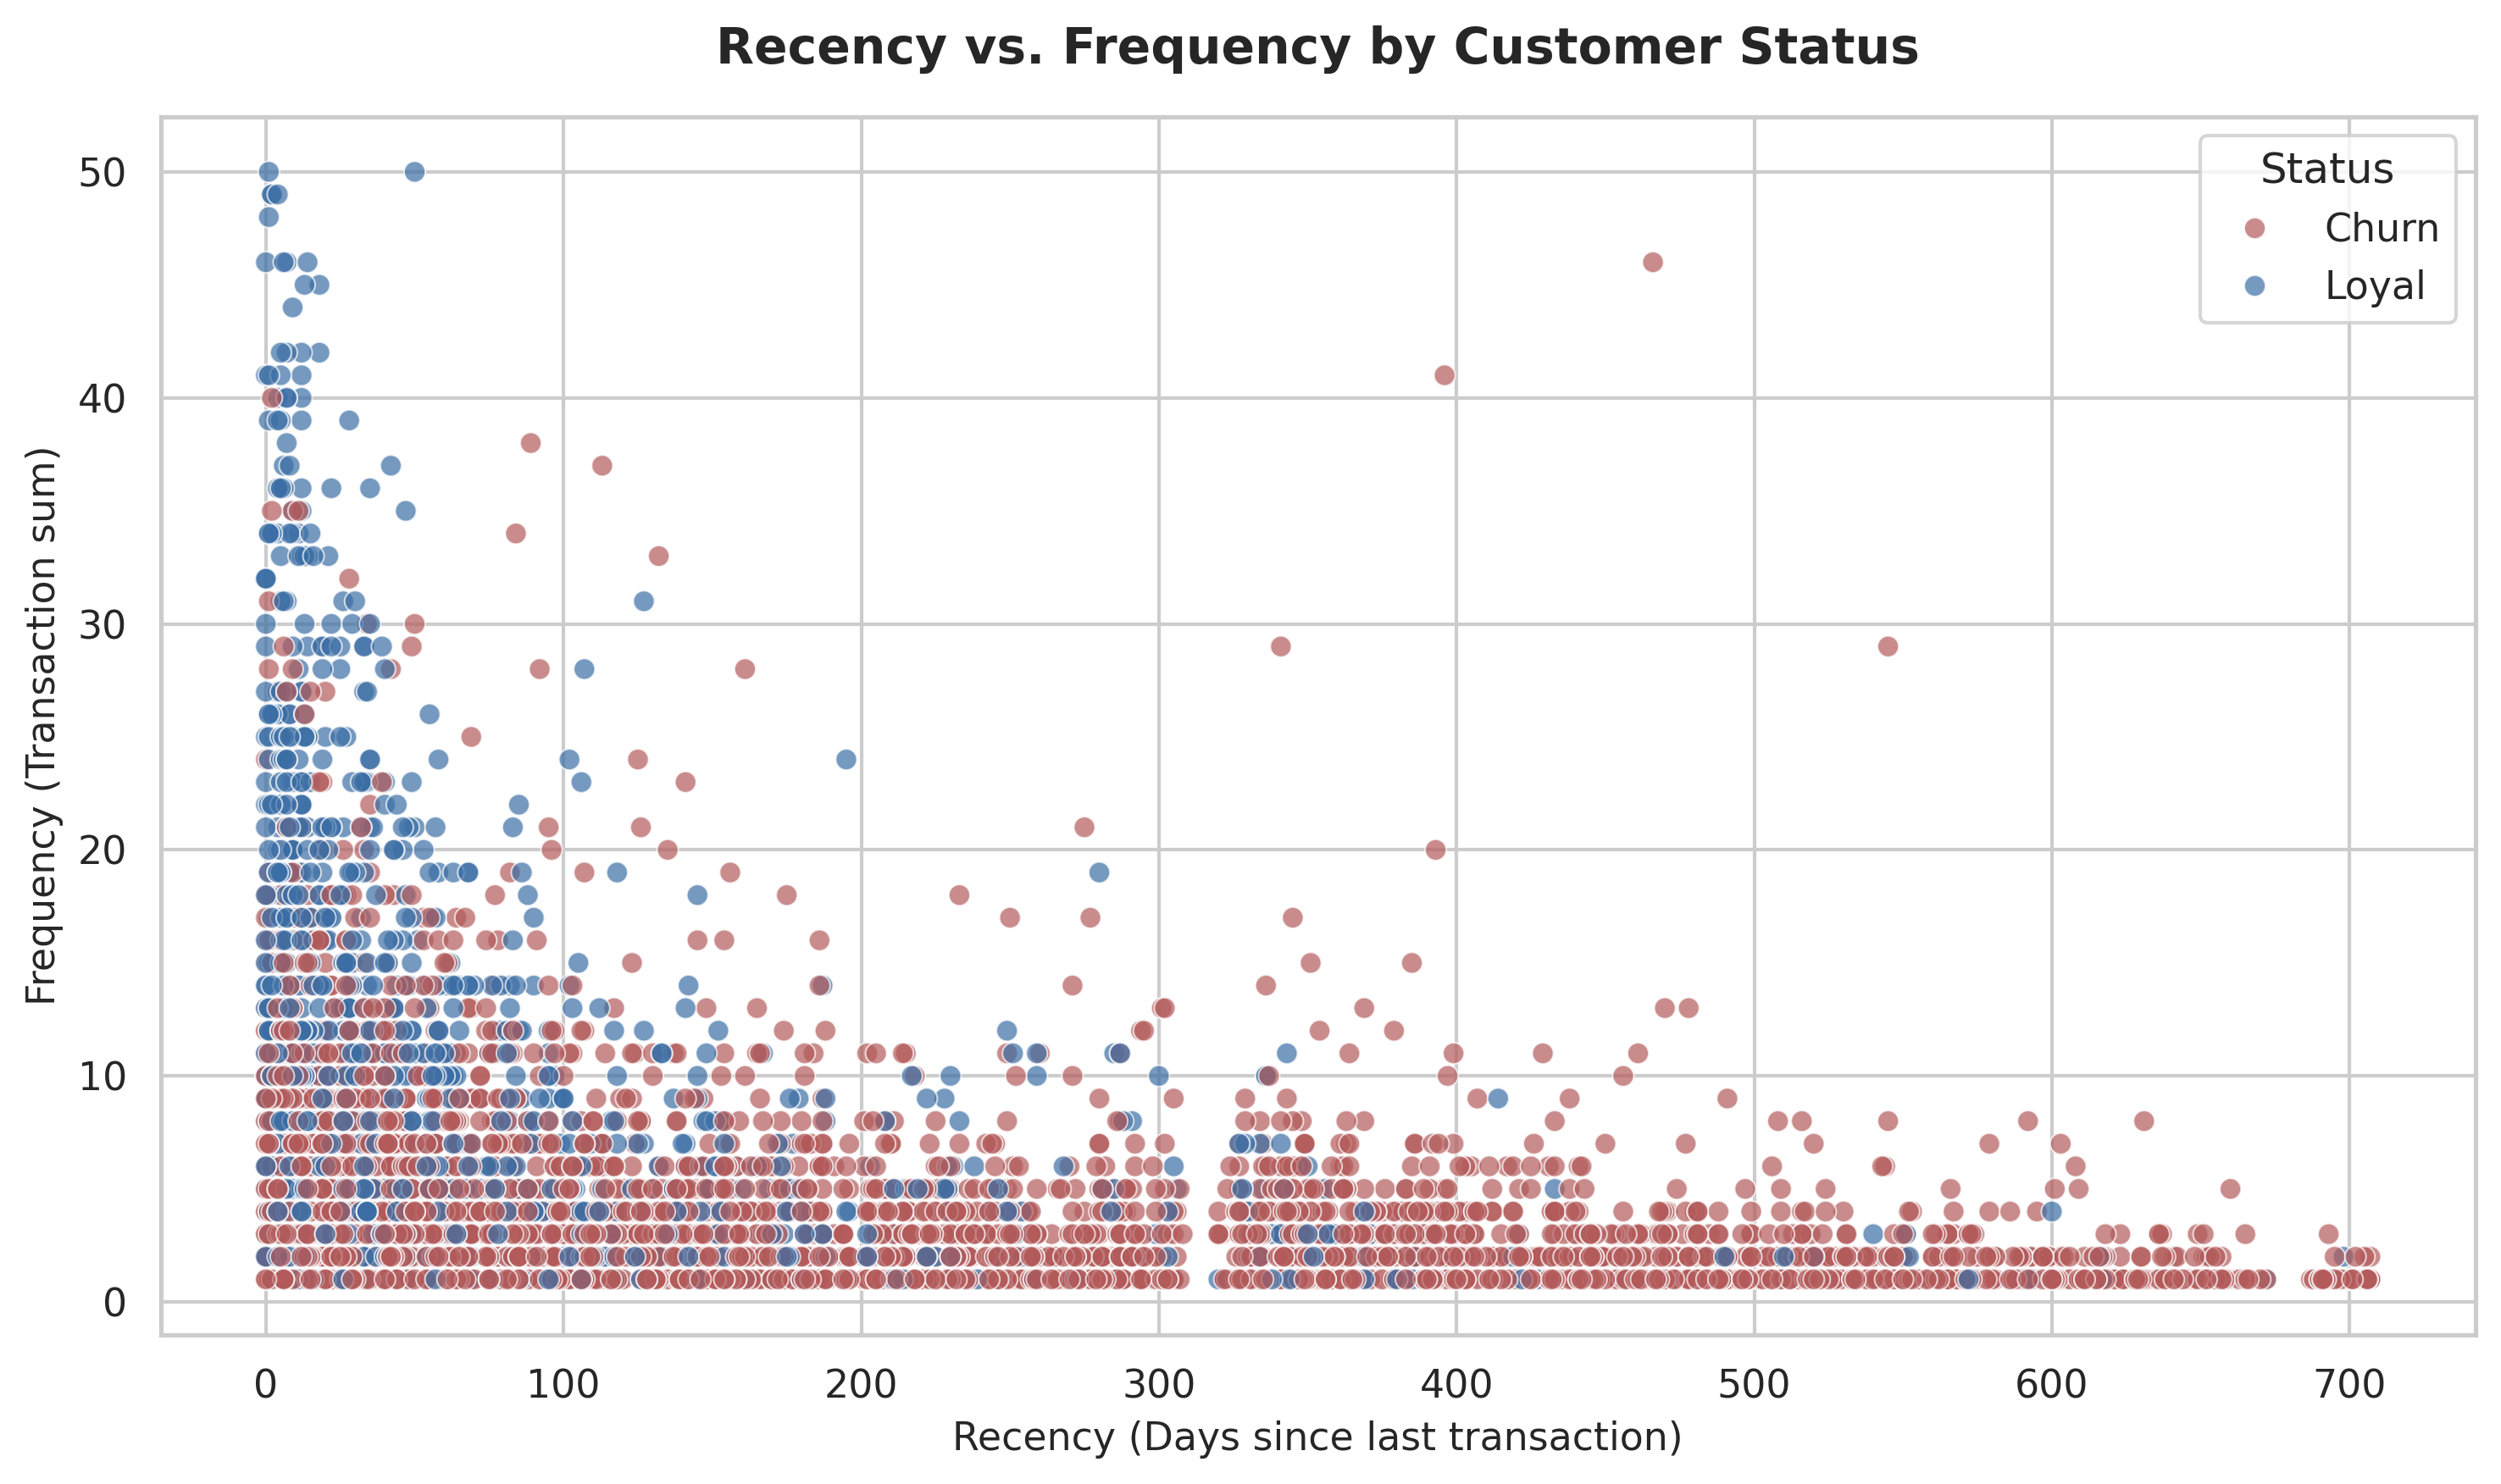

Generating Plot 4: Concept Drift Analysis...


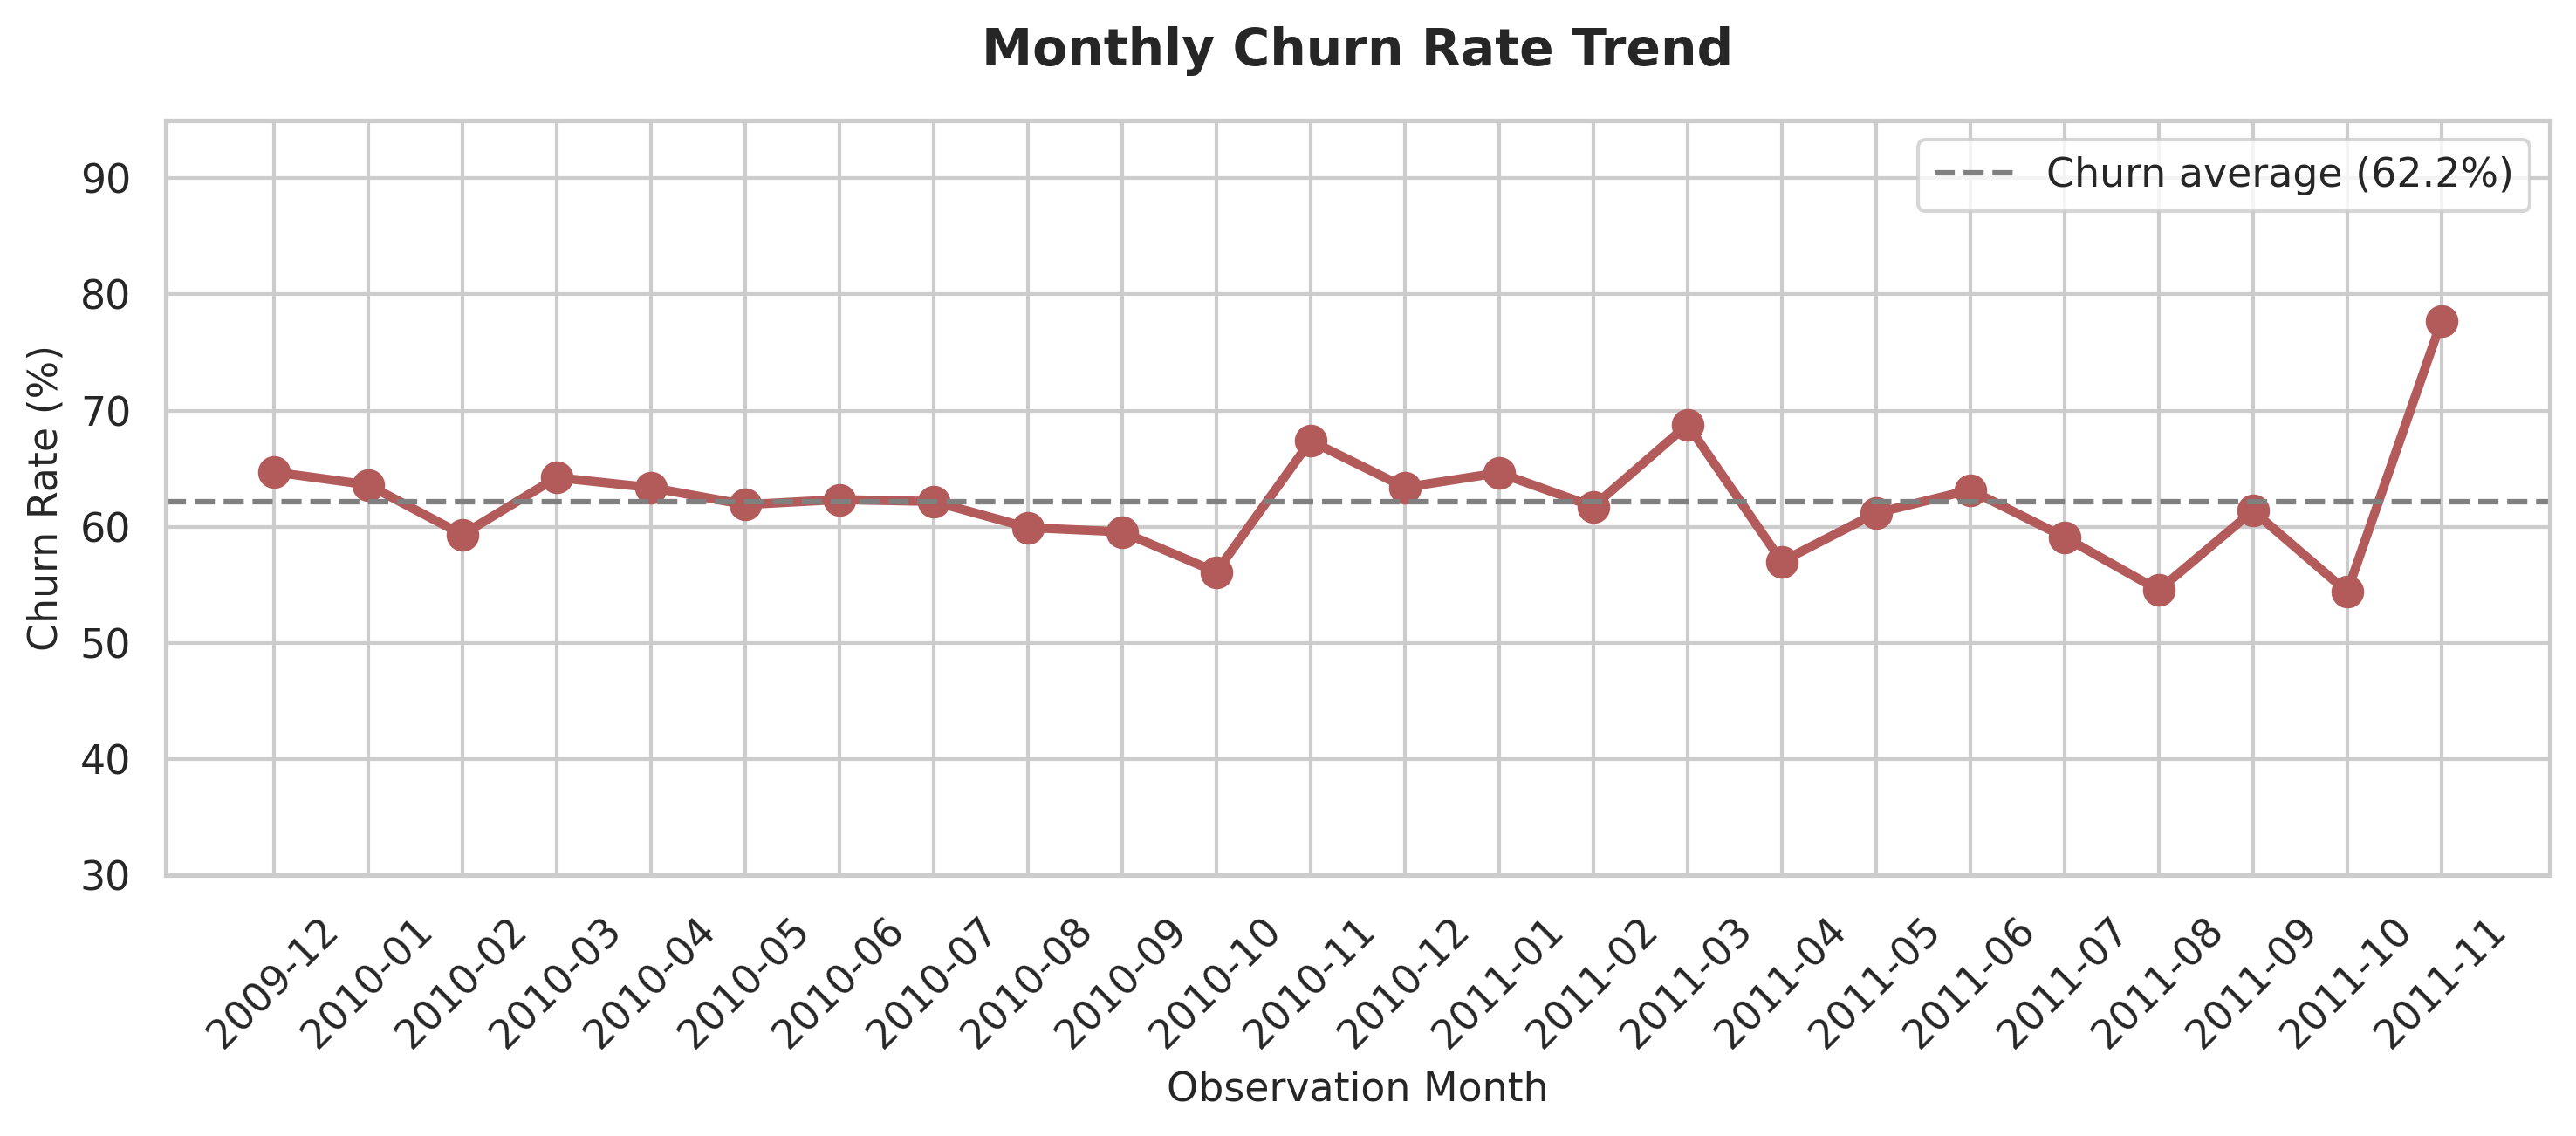

--- SELURUH PROSES PREPROCESSING DAN EDA SELESAI ---


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# TAHAP 1: GATHERING & PRE-PROCESSING DATA
print("--- TAHAP 1: GATHERING & PRE-PROCESSING DATA ---")
print("Loading data...")

# 1. Load Data (Ganti jadi .xlsx kalau aslinya format excel)
df = pd.read_csv('online_retail_II.csv')
print(f"Jumlah baris awal: {len(df):,}")

# 2. Rename nama kolom agar sama dengan format kodingan utama
df = df.rename(columns={
    'InvoiceNo': 'Invoice',
    'CustomerID': 'Customer ID',
    'UnitPrice': 'Price'
})

# 3. Pre-processing
# a. Hapus baris dengan Customer ID kosong
df = df.dropna(subset=['Customer ID']).copy()

# b. Hapus transaksi pembatalan (Invoice berawalan 'C')
df['Invoice'] = df['Invoice'].astype(str)
df = df[~df['Invoice'].str.startswith('C')]

# c. Hapus harga atau kuantitas negatif/nol
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# d. Hitung Total Pembelanjaan (Monetary) dan ubah ke format datetime
df['TotalValue'] = df['Quantity'] * df['Price']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"Jumlah baris setelah pre-processing (Data Bersih): {len(df):,}")
print(f"Rentang Waktu Data: {df['InvoiceDate'].min().date()} hingga {df['InvoiceDate'].max().date()}")


# TAHAP 2: EXPLORATORY DATA ANALYSIS (EDA)
print("\n--- TAHAP 2: MEMULAI GENERATE GRAFIK EDA ---")
sns.set_theme(style="whitegrid", palette="muted")

# --- PERSIAPAN DATA UNTUK EDA (Ambil 1 siklus untuk Scatter & Histplot) ---
obs_start = df['InvoiceDate'].min().normalize()
perf_end = df['InvoiceDate'].max().normalize()
obs_end = perf_end - pd.Timedelta(days=30)

obs_df = df[(df['InvoiceDate'] >= obs_start) & (df['InvoiceDate'] < obs_end)]
perf_df = df[(df['InvoiceDate'] >= obs_end) & (df['InvoiceDate'] <= perf_end)]

#fungsi untuk hitung jeda hari
def get_inter_purchase_time(series):
    if len(series) <= 1:
        return 0.0
    # Urutkan tanggal belanja dari yang paling lama ke baru, lalu hitung selisih harinya
    return series.sort_values().diff().dt.days.mean()

rfmt_eda = obs_df.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (obs_end - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalValue', 'sum'),
    Time=('InvoiceDate', get_inter_purchase_time)
).reset_index()

ret_custs = perf_df['Customer ID'].unique()
rfmt_eda['Status'] = np.where(rfmt_eda['Customer ID'].isin(ret_custs), 'Loyal', 'Churn')

# Isi nilai NaN dengan angka 0 (untuk customer yang baru belanja 1 kali)
rfmt_eda['Time'] = rfmt_eda['Time'].fillna(0).round(2)

# EDA 1 (countplot) -> MEMBUKTIKAN ANNUAL SEASONALITY
print("Generating Plot 1: Countplot Musiman per Bulan...")
plt.figure(figsize=(10, 5), dpi=300)

df['Month'] = df['InvoiceDate'].dt.month
sns.countplot(x='Month', data=df, palette='viridis')

plt.title('Monthly Transaction Volume', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Month (1 = January, 12 = December)', fontsize=11)
plt.ylabel('Total Transactions', fontsize=11)
plt.tight_layout()
plt.savefig('eda_1_countplot_seasonality.png')
plt.show()

# EDA 2 (histplot) -> MEMBUKTIKAN ALASAN PAKAI XGBOOST (SKEWNESS)
print("Generating Plot 2: Histplot Distribusi Fitur...")
plt.figure(figsize=(10, 5), dpi=300)

# Filter outlier agar grafik tidak rusak
freq_filtered = rfmt_eda[rfmt_eda['Frequency'] <= 50]
sns.histplot(freq_filtered['Frequency'], bins=30, kde=True, color='#439373')

plt.title('Customer Frequency Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Frequency (Transaction sum)', fontsize=11)
plt.ylabel('Customer Count', fontsize=11)
plt.tight_layout()
plt.savefig('eda_2_histplot_skewness.png')
plt.show()

# EDA 3 (scatterplot) -> MEMBUKTIKAN POLA NON-LINEAR
print("Generating Plot 3: Scatter Plot Recency vs Frequency...")
plt.figure(figsize=(10, 6), dpi=300)

sns.scatterplot(
    x='Recency',
    y='Frequency',
    hue='Status',
    data=freq_filtered,
    palette={'Loyal': '#3b6ea5', 'Churn': '#b35a5a'},
    alpha=0.7
)

plt.title('Recency vs. Frequency by Customer Status', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Recency (Days since last transaction)', fontsize=11)
plt.ylabel('Frequency (Transaction sum)', fontsize=11)
plt.tight_layout()
plt.savefig('eda_3_scatter_rfmt.png')
plt.show()

# EDA 4 BUKTI CONCEPT DRIFT (FLUKTUASI CHURN RATE BULANAN)
print("Generating Plot 4: Concept Drift Analysis...")
monthly_users = df.groupby(df['InvoiceDate'].dt.to_period('M'))['Customer ID'].unique()
months = monthly_users.index

churn_rates, valid_months = [], []
for i in range(len(months)-1):
    current_users = set(monthly_users[months[i]])
    next_users = set(monthly_users[months[i+1]])
    retained = len(current_users.intersection(next_users))
    churn_rate = (1.0 - (retained / len(current_users))) * 100
    churn_rates.append(churn_rate)
    valid_months.append(str(months[i]))

plt.figure(figsize=(10, 4.5), dpi=300)
plt.plot(valid_months, churn_rates, marker='o', color='#b35a5a', linewidth=2.5, markersize=8)
plt.title('Monthly Churn Rate Trend', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Observation Month', fontsize=11)
plt.ylabel('Churn Rate (%)', fontsize=11)
plt.xticks(rotation=45)
plt.axhline(np.mean(churn_rates), color='gray', linestyle='--', label=f'Churn average ({np.mean(churn_rates):.1f}%)')
plt.ylim(30, 95)
plt.legend()
plt.tight_layout()
plt.savefig('eda_4_concept_drift.png')
plt.show()

print("--- SELURUH PROSES PREPROCESSING DAN EDA SELESAI ---")

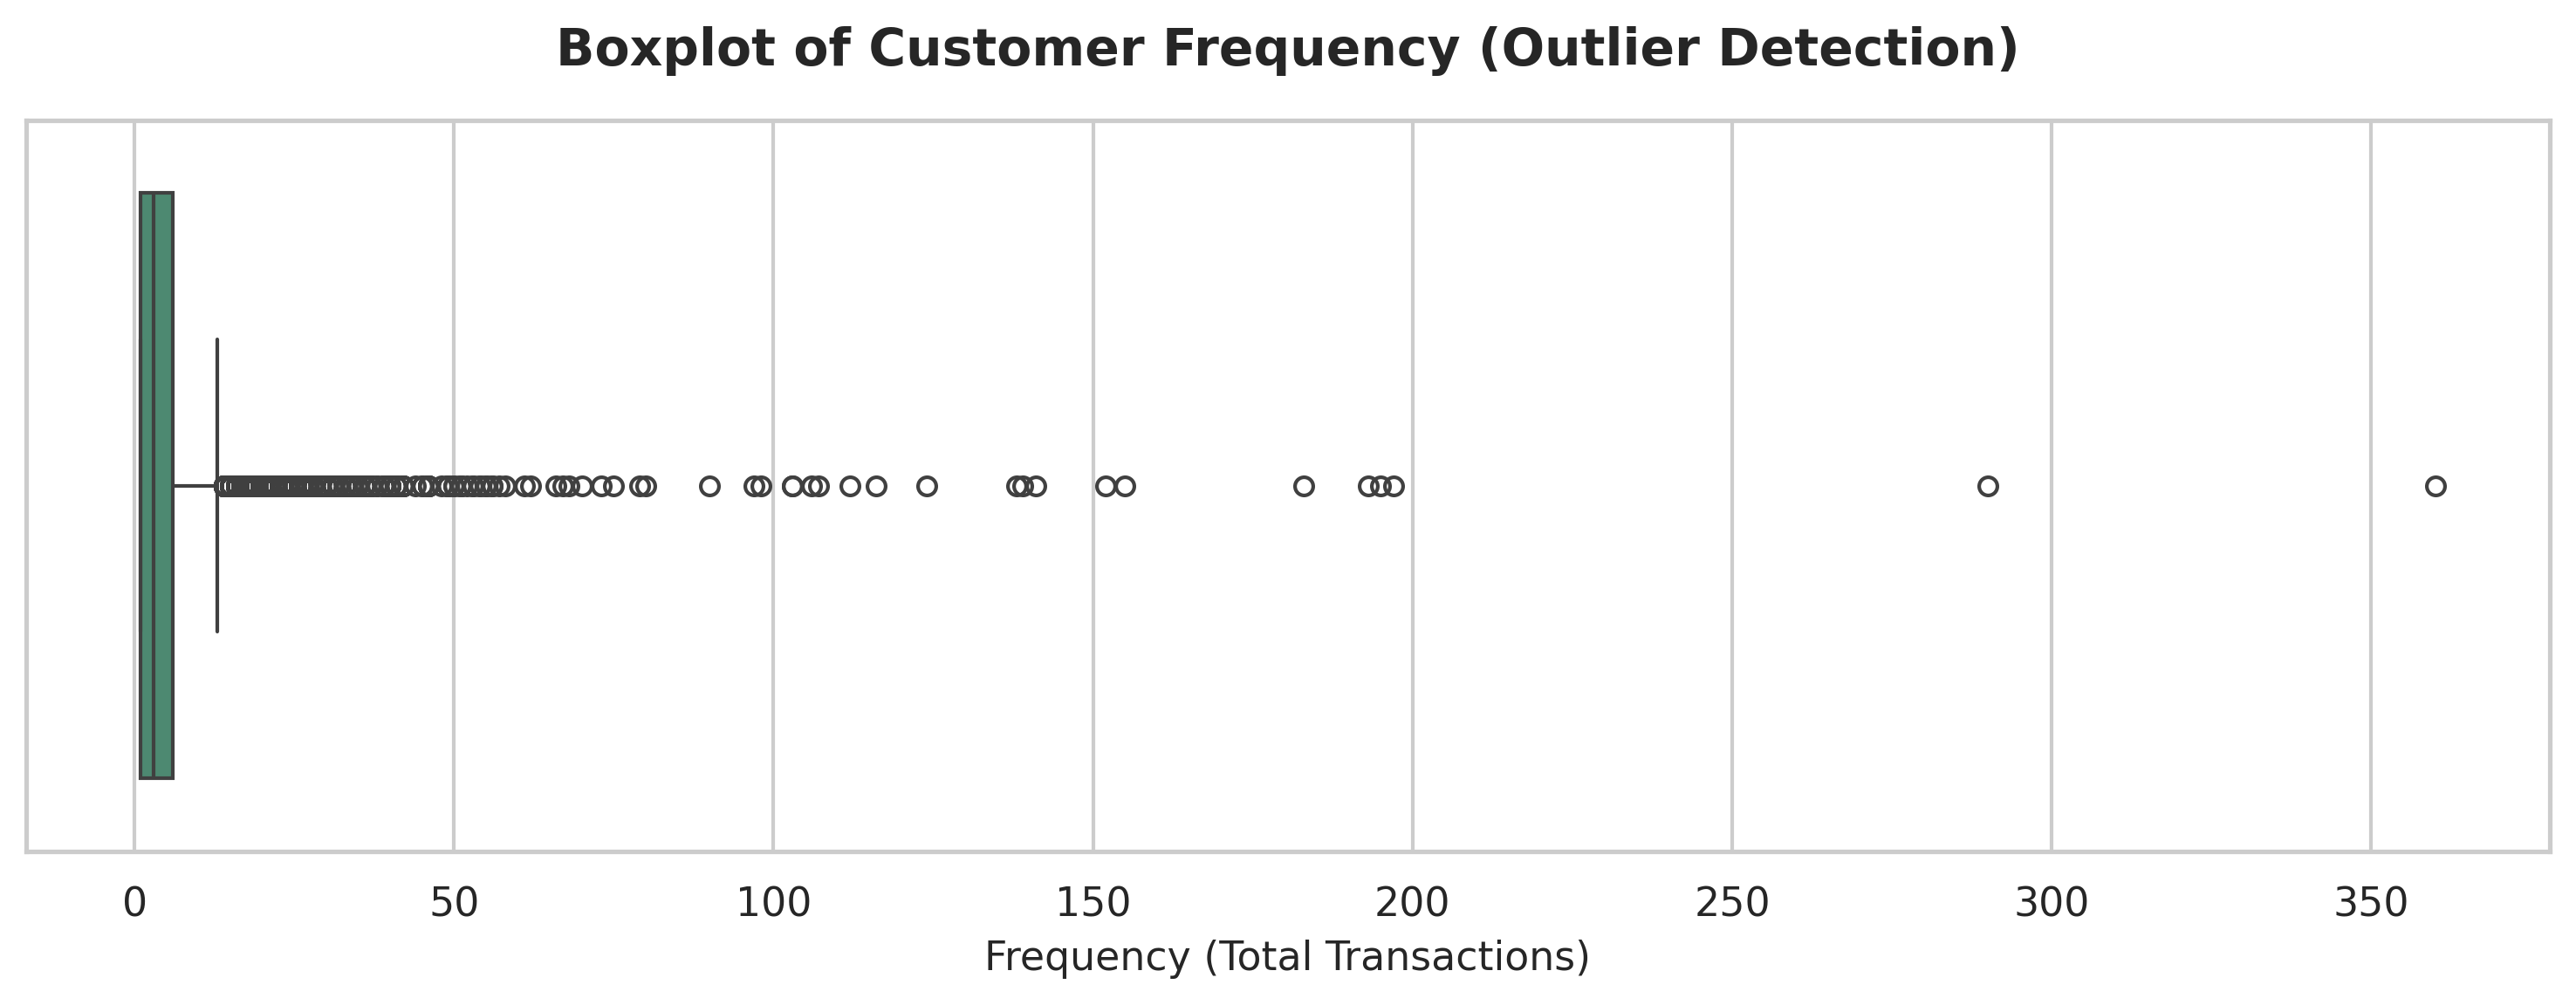

In [ ]:
plt.figure(figsize=(10, 4), dpi=300)

sns.boxplot(x=rfmt_eda['Frequency'], color='#439373', fliersize=5)

plt.title('Boxplot of Customer Frequency (Outlier Detection)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Frequency (Total Transactions)', fontsize=11)
plt.tight_layout()
plt.show()

Generating Plot 6: Histplot Jeda Hari Belanja (Time)...


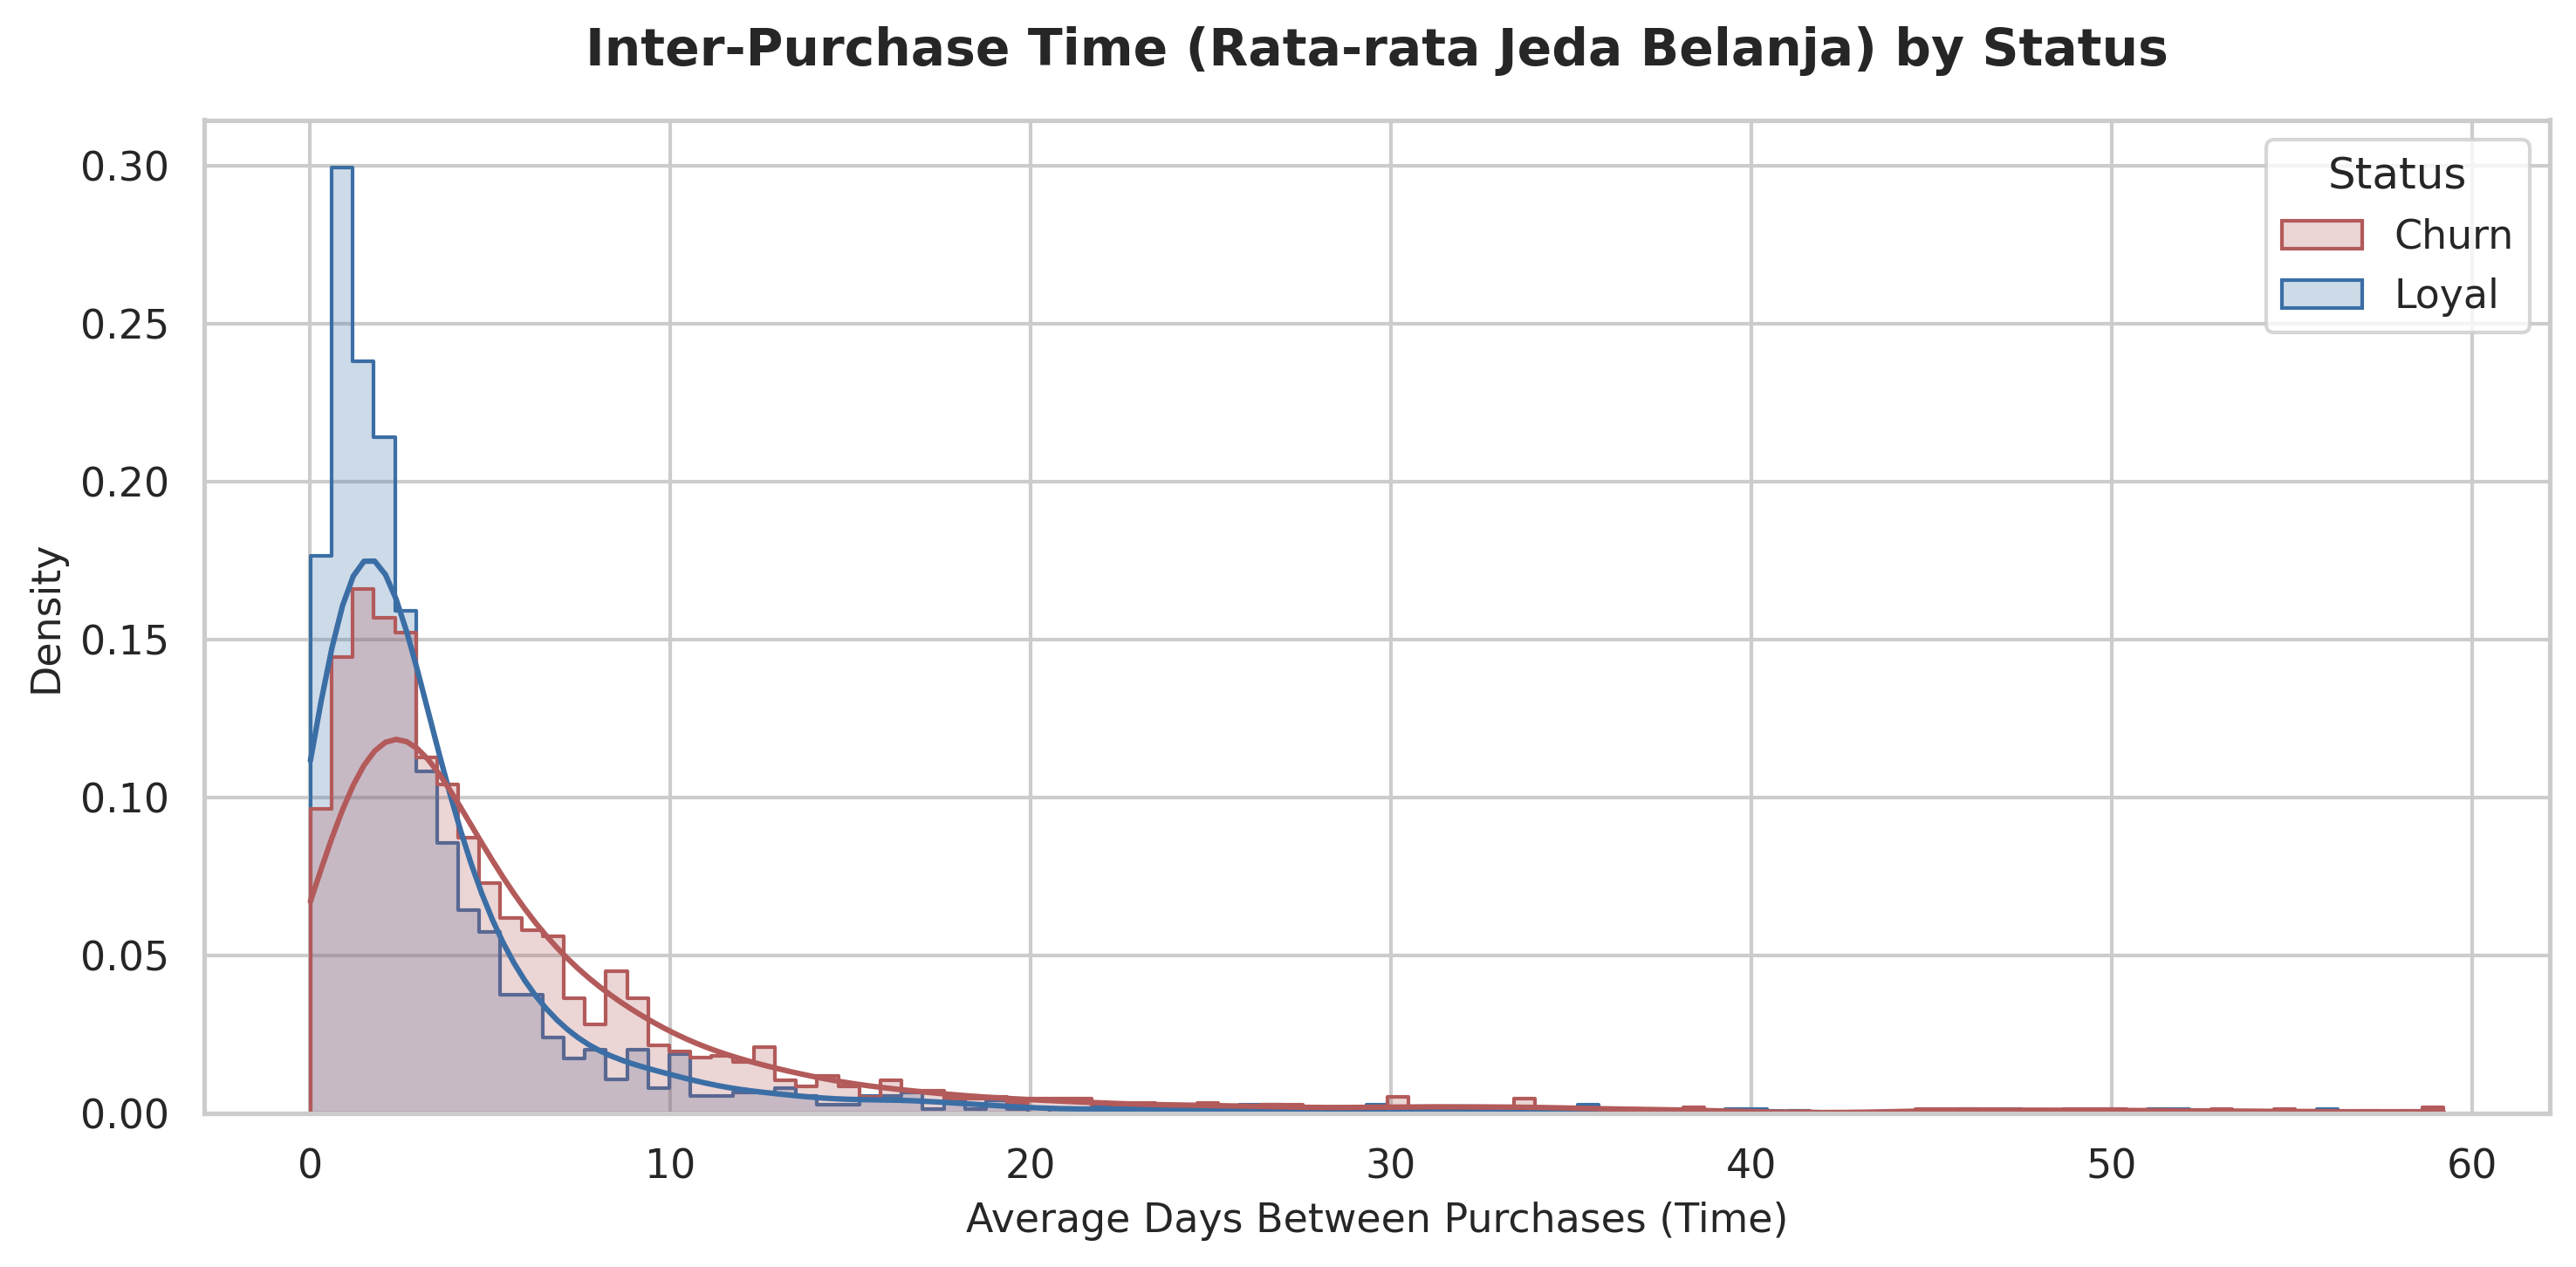

In [ ]:
print("Generating Plot 6: Histplot Jeda Hari Belanja (Time)...")
plt.figure(figsize=(10, 5), dpi=300)

# filter: HANYA ambil Repeat Buyer (Time > 0) sampai batas 60 hari
time_filtered = rfmt_eda[(rfmt_eda['Time'] > 0) & (rfmt_eda['Time'] <= 60)]

sns.histplot(
    data=time_filtered,
    x='Time',
    hue='Status',
    kde=True,
    palette={'Loyal': '#3b6ea5', 'Churn': '#b35a5a'},
    element='step',
    stat='density',
    common_norm=False
)

plt.title('Inter-Purchase Time (Rata-rata Jeda Belanja) by Status', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Days Between Purchases (Time)', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.tight_layout()
plt.show()